# Fitting the source galaxy clustering bias to DES Y3

Following section 3 of [Thomsen et al. 2025](https://arxiv.org/abs/2511.04681), the source galaxy number counts of a metacal tomographic bin are modelled as

$$ n_{g,s}^i = \langle n_{g,s}^i \rangle \left( 1 + b_{g,s}^i \frac{\delta_m^i - \langle \delta_m^i \rangle}{\langle \delta_m^i \rangle} \right) $$

and Poisson sampled. The linear source clustering bias $b_{g,s}^i$ is fixed per cosmology by **matching the pixel histogram of the galaxy counts to a reference observation**, which absorbs the cosmology dependence of the one-point source galaxy distribution into the bias. The shape noise generator then draws as many galaxies from the real DES Y3 shear catalog as there are galaxies in a given pixel.

The reference observation was Buzzard in the paper above and is **DES Y3** here.

## The imaging systematics go on the model side

The DES Y3 count map carries imaging systematics (depth, seeing, stellar density, ...) that CosmoGrid does not have, and the fit has nowhere to put them but into $b$ — which is why the earlier fits returned an implausible $b \approx 3$ in the highest tomographic bin.

The correction therefore goes on the **simulation** side: the model density is **contaminated** with the DES imprint before it is Poisson sampled, while the target stays the raw, unmodified observation. The data is the data — the forward model has to reproduce what the survey actually observed, and decontaminating the observation instead would fit a target that the pipeline is never asked to produce.

This notebook runs two arms,

| arm | model | target |
|---|---|---|
| `clean` | CosmoGrid as is | raw DES Y3 |
| `contam` | CosmoGrid $\times$ contamination | raw DES Y3 |

and writes one bias table each. The correction map is `data/metacal_sources_STD32_512.h5`, the nside 512 product of the `lss_sys` ISD pipeline, read by `files.get_metacal_systematics`.

## The rest of the fit

It lives in `msfm.utils.source_clustering_bias`, an in-package reimplementation of `dev/scripts/source_galaxy_clustering_bias/jozef_code/optimize_biases_parallel_desy3.py` by Jozef Bucko. That script stays unchanged as the reference. The deviations from it are

1. the loss is the actual 1D Wasserstein distance between the two pixel count distributions, rather than the Wasserstein distance between the multisets of histogram bin heights (which is permutation invariant across bins),
2. `n_bar` is measured on the reference observation and asserted against `survey.metacal.n_gal`,
3. the one-point function is evaluated on the footprint pixels only, which is ~10x faster and makes the clip renormalization conserve galaxies over exactly the region `n_bar` was measured on,
4. the fiducial cosmology is fit directly rather than aliased to the closest grid cosmology.

**Run this on a compute node with the TensorFlow environment active**, asking for the whole node so that the full grid cell gets all 288 cores.

In [1]:
import os

import numpy as np
import h5py
import matplotlib.pyplot as plt

from msfm.utils import files, catalog, cosmogrid, imports, source_clustering_bias as scb

hp = imports.import_healpy()

In [2]:
repo_dir = "/users/athomsen/dlss/repos/multiprobe-simulation-forward-model"
conf = files.load_config(os.path.join(repo_dir, "configs/v18/baseline.yaml"))

# CosmoGrid v11desy3 projected probe maps on Clariden
cosmogrid_dir = "/iopsstor/scratch/cscs/athomsen/CosmoGrid/v11desy3/bary"
fiducial_dir = os.path.join(cosmogrid_dir, "fiducial", "cosmo_fiducial")

# one new bias table per arm, the existing data/metacal_biases_desy3.h5 is left untouched
out_files = {
    "clean": os.path.join(repo_dir, "data/metacal_biases_desy3_v2.h5"),
    "contam": os.path.join(repo_dir, "data/metacal_biases_desy3_v2_sys.h5"),
}
colors = {"clean": "C0", "contam": "C2"}

z_bins = conf["survey"]["metacal"]["z_bins"]
n_z = len(z_bins)
n_side = conf["analysis"]["n_side"]
n_pix = hp.nside2npix(n_side)

# Target: the DES Y3 pixel count histograms

`build_target` restricts the DES Y3 metacal count map to the footprint and histograms the counts of each tomographic bin into 200 bins covering 1 to 200 galaxies per pixel. Empty pixels are excluded by the lower bin edge of 0.5. The count map comes from the `data/metacal_wl_count_map.npy` cache, so no catalog access is needed.

This target is the same for both arms and is never modified.

In [3]:
_, count_map = catalog.build_metacal_map_from_cat(conf, debug=False)
target, n_bar, mask = scb.build_target(conf, count_map=count_map)

n_bar_conf = np.array(conf["survey"]["metacal"]["n_gal"]) * hp.nside2pixarea(n_side, degrees=True)
print("n_bar (DES Y3 map) =", np.round(n_bar, 3))
print("n_bar (config)     =", np.round(n_bar_conf, 3))
print(f"footprint          = {mask.sum()} pixels ({100 * mask.mean():.1f}% of the sky)")

26-08-03 15:25:10   catalog.py INF   Loaded metacal maps from cache 


26-08-03 15:25:11 source_clust INF   Mean galaxy counts per pixel: [72.2  73.25 72.11 73.16] (config: [72.2  73.25 72.11 73.16]) 


n_bar (DES Y3 map) = [72.203 73.25  72.106 73.159]
n_bar (config)     = [72.203 73.25  72.106 73.159]
footprint          = 318616 pixels (10.1% of the sky)


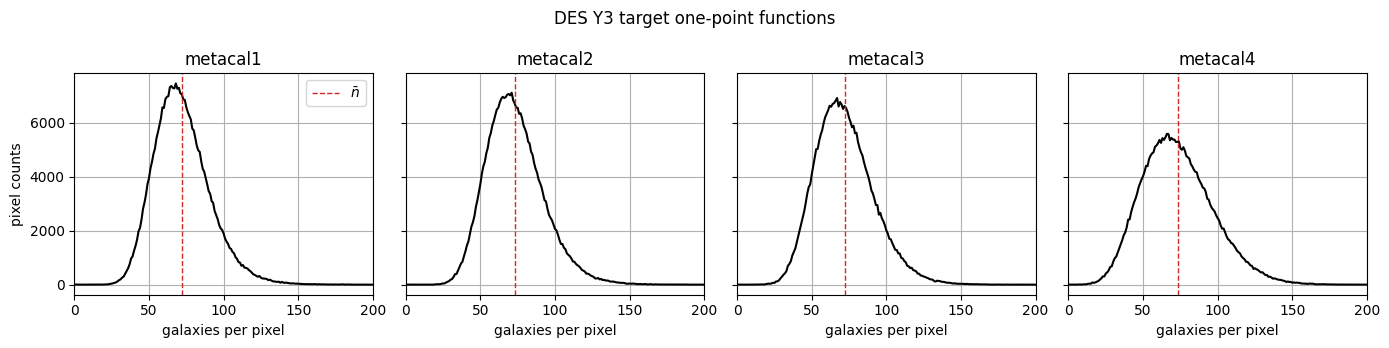

In [4]:
centres = scb._bin_centres_1pt()

fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z, sharey=True)
for i in range(n_z):
    ax[i].plot(centres, target[i], color="black", lw=1.5)
    ax[i].axvline(n_bar[i], color="C3", ls="--", lw=1, label=r"$\bar{n}$")
    ax[i].set(xlabel="galaxies per pixel", title=z_bins[i], xlim=(0, 200))
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="pixel counts")
ax[0].legend()
fig.suptitle("DES Y3 target one-point functions")
fig.tight_layout()

# The contamination map

`files.get_metacal_systematics` reads the `lss_sys` maps and brings them into the frame of the forward model. Three things matter:

- **which dataset.** The file carries `weight` $= \langle W \rangle$, which *decontaminates* observed counts, and `contamination` $= \langle 1/W \rangle$, which *imposes* the DES imprint on a clean model. They are not reciprocals of each other — averaging over sub pixels does not commute with inverting, and they differ by up to 12.7% in bin 3. The forward model needs `contamination`.
- **the frame.** The maps are stored in celestial coordinates, whereas the forward model works in the rotated footprint frame of Fig. 4 of the paper. They are rotated with the very same `hp.Rotator` that `notebooks/pixel_file.ipynb` used to build the mask and the maglim systematics maps, with the off-footprint value set to 1 (no correction) first so that the interpolation does not bleed into the footprint. That rotation does not preserve pixels, so it smooths the map slightly at the pixel scale — quantified below.
- **the normalization.** The maps carry unit mean over their own footprint, which is wider than the thresholded analysis mask, so they are renormalized to unit mean over the base patch. That makes the contamination conserve the total galaxy count over exactly the footprint that $\bar{n}$ is measured on.

In [5]:
contamination = files.get_metacal_systematics(conf)
weight = files.get_metacal_systematics(conf, dataset="weight")
print("contamination", contamination.shape, "= (footprint pixels, tomographic bins)")

# the rotation is the one that defines the mask and the patches, so it has to cover the footprint exactly
base_patch_pix = np.arange(n_pix)[mask]
ra, dec = catalog.survey_pix_to_angles(conf, base_patch_pix, n_side)
assert np.array_equal(catalog.survey_angles_to_pix(conf, ra, dec, n_side), base_patch_pix)
print(f"rotation round trip exact on all {len(base_patch_pix)} footprint pixels")

# how much of the pixel scale structure the rotation smooths away, and the sub percent level residual of <1/W> vs 1/<W>
with h5py.File(os.path.join(repo_dir, conf["files"]["metacal_systematics"]), "r") as f:
    raw = [f[f"bin{i}/contamination"][:] for i in range(n_z)]
std_raw = [c[c != 0].std() for c in raw]

for i in range(n_z):
    print(
        f"bin {i + 1}: C in [{contamination[:, i].min():.3f}, {contamination[:, i].max():.3f}], "
        f"<C> = {contamination[:, i].mean():.6f}, std {contamination[:, i].std():.4f} "
        f"(before the rotation {std_raw[i]:.4f}), median |C * W - 1| = "
        f"{np.median(np.abs(contamination[:, i] * weight[:, i] - 1)):.4f}"
    )

26-08-03 15:25:12     files.py INF   Reading the contamination maps of the imaging systematics run 'metacal_sources_STD32' at nside 512 (lss_sys acfd389f) 


26-08-03 15:25:14     files.py INF   Reading the weight maps of the imaging systematics run 'metacal_sources_STD32' at nside 512 (lss_sys acfd389f) 


contamination (318616, 4) = (footprint pixels, tomographic bins)
rotation round trip exact on all 318616 footprint pixels
bin 1: C in [0.781, 1.196], <C> = 1.000000, std 0.0570 (before the rotation 0.0602), median |C * W - 1| = 0.0035
bin 2: C in [0.712, 1.289], <C> = 1.000000, std 0.0824 (before the rotation 0.0877), median |C * W - 1| = 0.0073
bin 3: C in [0.674, 1.299], <C> = 1.000000, std 0.0967 (before the rotation 0.1009), median |C * W - 1| = 0.0101


bin 4: C in [0.360, 1.932], <C> = 1.000000, std 0.2220 (before the rotation 0.2448), median |C * W - 1| = 0.0530


The three columns below mirror `<label>_maps.png` of `lss_sys`: the contamination map, the raw density contrast of the observation and the decontaminated one. The rotation is verified by the map landing exactly on the footprint. A working correction shows visibly less large scale structure in the third column.

The third column is a **diagnostic of the correction map only** — it is not the target of any fit, and it is the one place in this notebook where the `weight` dataset is used.

26-08-03 15:25:16 source_clust INF   Rescaled the corrected counts by [1.0038 1.0075 1.0104 1.0562] to conserve galaxies 


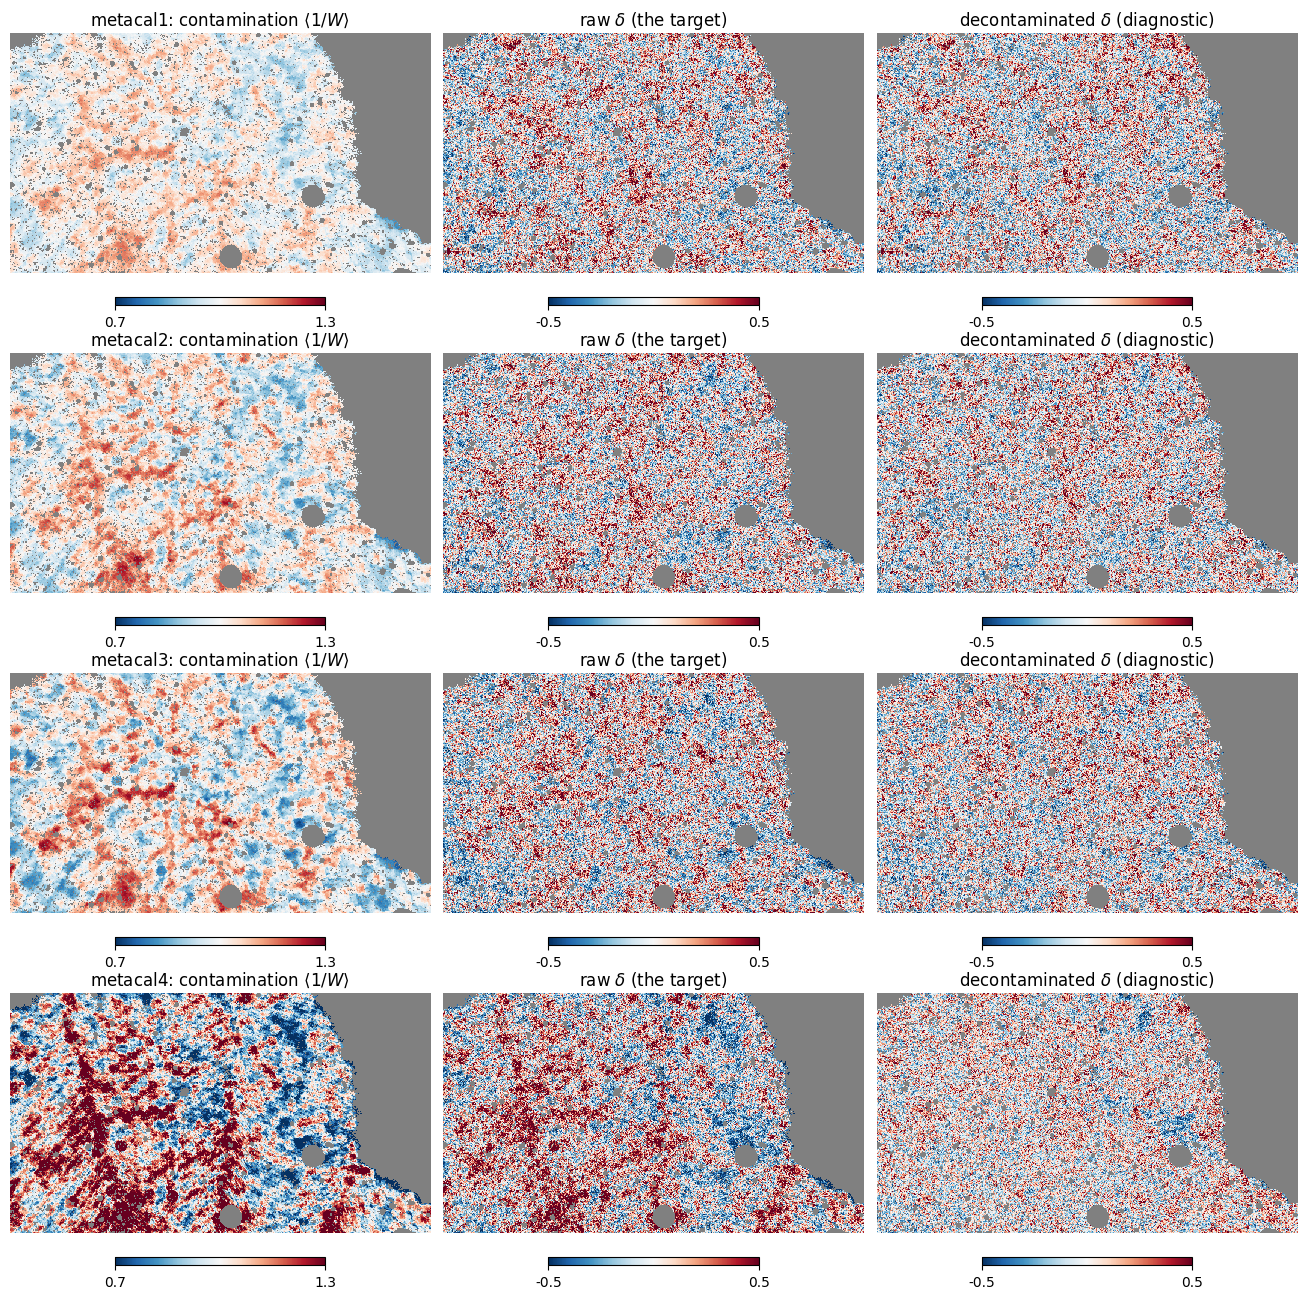

In [6]:
counts_decontaminated = scb.decontaminate_counts(count_map[mask], weight)

# centre the gnomonic projection on the footprint, which the rotation moved away from the DES sky position
lon, lat = hp.vec2ang(np.array(hp.pix2vec(n_side, base_patch_pix)).mean(axis=1), lonlat=True)


def masked(values):
    """Scatter a footprint array onto the sphere, everything else is grey."""
    full = np.full(n_pix, hp.UNSEEN)
    full[mask] = values
    return hp.ma(full)


fig = plt.figure(figsize=(13, 3.2 * n_z))
for i in range(n_z):
    d_raw = count_map[mask, i] / n_bar[i] - 1
    d_dec = counts_decontaminated[:, i] / np.mean(counts_decontaminated[:, i]) - 1
    for j, (m, title, lim) in enumerate(
        [
            (contamination[:, i], f"{z_bins[i]}: contamination $\\langle 1/W \\rangle$", (1 - 0.3, 1 + 0.3)),
            (d_raw, "raw $\\delta$ (the target)", (-0.5, 0.5)),
            (d_dec, "decontaminated $\\delta$ (diagnostic)", (-0.5, 0.5)),
        ]
    ):
        hp.gnomview(
            masked(m),
            rot=(lon[0], lat[0]),
            reso=7,
            xsize=700,
            ysize=400,
            min=lim[0],
            max=lim[1],
            cmap="RdBu_r",
            title=title,
            notext=True,
            cbar=True,
            sub=(n_z, 3, 3 * i + j + 1),
        )

### What the contamination does to the model

The direct statement of the hypothesis: the simulated one-point function is too narrow, and the contamination has to widen it. Below is the standard deviation of the simulated footprint counts at the fiducial cosmology, held at $b = 1$ so that only the contamination moves, against the observed width.

If the contaminated model is *narrower* than the clean one, the wrong dataset is being used.

In [7]:
delta = scb.read_density_contrast(conf, fiducial_dir)
print("delta", delta.shape, "mean", delta.mean(axis=0).round(4), "std", delta.std(axis=0).round(3))

arms = {"clean": None, "contam": contamination}

print("\nstd of the footprint galaxy counts at the fiducial cosmology, b = 1")
print("            " + "".join(f"   {z:>8s}" for z in z_bins))
for name, contam in arms.items():
    stds = [
        scb.counts_from_bias(
            n_bar[i], delta[mask, i], 1.0, contamination=None if contam is None else contam[:, i]
        ).std()
        for i in range(n_z)
    ]
    print(f"  {name:8s}  " + "".join(f"   {s:8.3f}" for s in stds))
print("  DES Y3    " + "".join(f"   {s:8.3f}" for s in count_map[mask].std(axis=0)))

delta (3145728, 4) mean [-0.  0.  0. -0.] std [0.258 0.175 0.138 0.102]

std of the footprint galaxy counts at the fiducial cosmology, b = 1
               metacal1   metacal2   metacal3   metacal4
  clean          20.257     15.303     13.059     11.284
  contam         20.685     16.441     14.890     19.933
  DES Y3         18.660     19.230     19.538     23.650


# A single cosmology

Fit the fiducial cosmology in both arms. The CosmoGrid maps are stored at nside 1024 and are downgraded to the analysis nside by `read_density_contrast`. If the systematics hypothesis is right, the contaminated model needs a **smaller** bias to reach the observed width, most in the highest tomographic bin.

In [8]:
fits = {name: scb.fit_bias(delta, target, n_bar, mask=mask, kind="1pt", contamination=c) for name, c in arms.items()}

for name, (b, loss, _) in fits.items():
    print(f"b_gs ({name:6s}) = {np.round(b, 4)}   losses = {np.round(loss, 5)}")
print("ratio contam/clean =", np.round(fits["contam"][0] / fits["clean"][0], 4))

b_gs (clean ) = [0.9876 1.3953 1.8106 3.0576]   losses = [1.77674 1.0805  0.56313 0.45656]
b_gs (contam) = [0.9569 1.3124 1.6552 1.9813]   losses = [1.65395 0.94355 0.57663 0.938  ]
ratio contam/clean = [0.9689 0.9406 0.9141 0.648 ]


### Cost profile

The Poisson seed is held fixed across the cost function evaluations of a fit, which is what makes the objective a deterministic and smooth function of the bias. Scanning it confirms that Nelder-Mead is minimizing a well behaved unimodal profile rather than chasing Poisson noise.

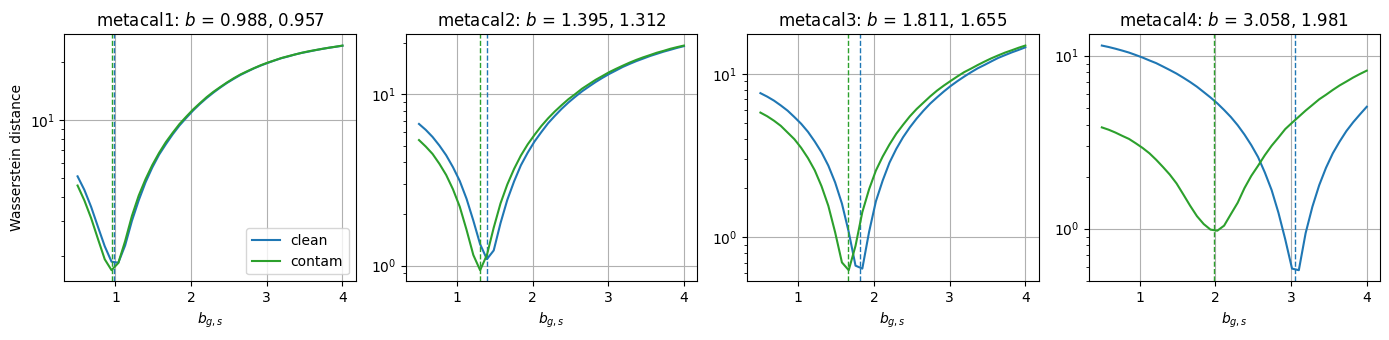

In [9]:
b_scan = np.linspace(0.5, 4.0, 40)

fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z, sharey=False)
for i in range(n_z):
    for name, contam in arms.items():
        contam_i = None if contam is None else contam[:, i]
        profile = [
            scb._cost(b, delta[mask, i], n_bar[i], target[i], "1pt", i, mask, scb.DEFAULT_SEED, contam_i)
            for b in b_scan
        ]
        ax[i].plot(b_scan, profile, color=colors[name], label=name)
        ax[i].axvline(fits[name][0][i], color=colors[name], ls="--", lw=1)
    ax[i].set(xlabel="$b_{g,s}$", title=f"{z_bins[i]}: $b$ = " + ", ".join(f"{fits[n][0][i]:.3f}" for n in arms))
    ax[i].set(yscale="log")
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="Wasserstein distance")
ax[0].legend()
fig.tight_layout()

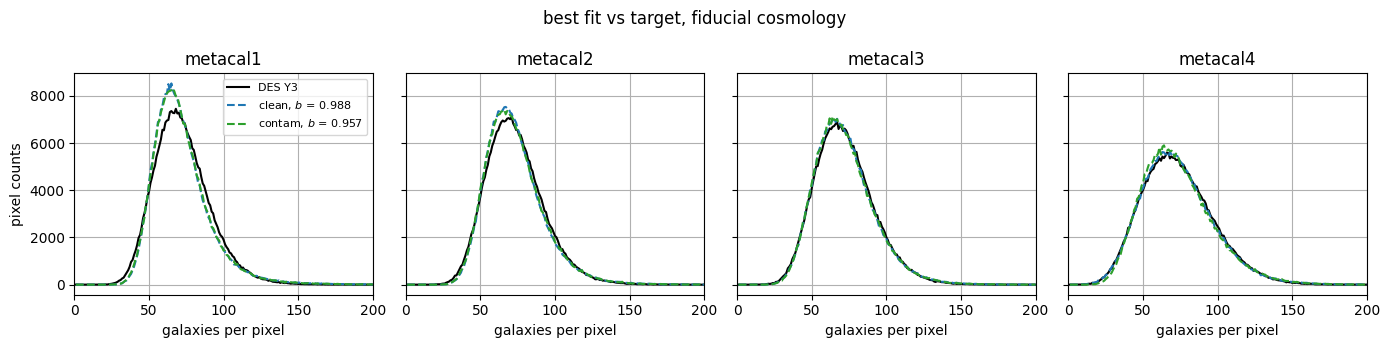

In [10]:
fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z, sharey=True)
for i in range(n_z):
    ax[i].plot(centres, target[i], color="black", lw=1.5, label="DES Y3")
    for name in arms:
        ax[i].plot(
            centres, fits[name][2][i], color=colors[name], lw=1.5, ls="--",
            label=f"{name}, $b$ = {fits[name][0][i]:.3f}",
        )
    ax[i].set(xlabel="galaxies per pixel", title=z_bins[i], xlim=(0, 200))
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="pixel counts")
ax[0].legend(fontsize=8)
fig.suptitle("best fit vs target, fiducial cosmology")
fig.tight_layout()

### Two-point cross-check

The paper matches the one-point function. The reference script also carries a two-point variant, which minimizes the squared difference of the log pseudo $C_\ell$ of the masked count maps over $30 \leq \ell < \ell_\mathrm{max}^i$. It is much slower (one `anafast` per cost evaluation) and is only used as a consistency check here.

It is a genuinely **independent** check: the ISD maps were built to remove spurious *large scale* power, which is what the low $\ell$ end of this statistic is made of, while the one-point function only knows about the width of the pixel distribution. The number to look at is how well the 1pt and 2pt biases agree in bin 4.

In [11]:
target_2pt, n_bar_2pt, _ = scb.build_target(conf, count_map=count_map, kind="2pt")
fits_2pt = {
    name: scb.fit_bias(delta, target_2pt, n_bar_2pt, mask=mask, kind="2pt", contamination=c)
    for name, c in arms.items()
}

for name in arms:
    b_1pt, b_2pt = fits[name][0], fits_2pt[name][0]
    print(f"b_gs ({name:6s}): 1pt {np.round(b_1pt, 4)}   2pt {np.round(b_2pt, 4)}")
    print(f"                  disagreement {np.round(100 * np.abs(b_2pt / b_1pt - 1), 1)} %")

26-08-03 15:25:34 source_clust INF   Mean galaxy counts per pixel: [72.2  73.25 72.11 73.16] (config: [72.2  73.25 72.11 73.16]) 


b_gs (clean ): 1pt [0.9876 1.3953 1.8106 3.0576]   2pt [0.8621 1.3008 1.6313 2.2751]
                  disagreement [12.7  6.8  9.9 25.6] %
b_gs (contam): 1pt [0.9569 1.3124 1.6552 1.9813]   2pt [0.8922 1.2938 1.5502 1.8498]
                  disagreement [6.8 1.4 6.3 6.6] %


### Comparison to the existing table

`data/metacal_biases_desy3.h5` was produced by the reference script with the permutation invariant loss and without any systematics correction, so it is the `clean` arm with a different loss.

In [12]:
# hardcoded rather than read from the config, which now points at the table this notebook writes
old_file = os.path.join(repo_dir, "data/metacal_biases_desy3.h5")
with h5py.File(old_file, "r") as f:
    biases_old = f["fiducial"][:]

print("b_gs (existing table) =", np.round(biases_old, 4))
for name in arms:
    print(f"b_gs ({name:6s})          = {np.round(fits[name][0], 4)}   "
          f"ratio to the existing table {np.round(fits[name][0] / biases_old, 3)}")

b_gs (existing table) = [1.1406 1.5066 1.8504 3.067 ]
b_gs (clean )          = [0.9876 1.3953 1.8106 3.0576]   ratio to the existing table [0.866 0.926 0.979 0.997]
b_gs (contam)          = [0.9569 1.3124 1.6552 1.9813]   ratio to the existing table [0.839 0.871 0.895 0.646]


# The full grid

2500 grid cosmologies plus the fiducial one, enumerated from the CosmoGridV1 metainfo file by `get_cosmogrid_dirs` and fit in a `multiprocessing.Pool`. Per cosmology this reads 4 nside 1024 `dg` maps (201 MB) and costs 1.6 s of IO plus 2.9 s of fitting, so the 2501 cosmologies are 3.1 CPU-hours. On a full Clariden node (288 cores) that comes out at **~66 s per arm**, i.e. a parallel efficiency of 0.6, the rest going into IO contention.

Each table records which forward model it was fit against in its `systematics_label` attribute, which `configuration.print_and_check_modeling_in_config` asserts against the `shape_noise.survey_systematics` setting of the config that consumes it.

In [13]:
cosmo_dirs = scb.get_cosmogrid_dirs(conf, cosmogrid_dir)

first = list(cosmo_dirs)[0]
print(f"{len(cosmo_dirs)} cosmologies, e.g. {first} -> {cosmo_dirs[first]}")
print(f"{len(os.sched_getaffinity(0))} cores available to this process")

26-08-03 15:27:37 source_clust INF   Enumerated 2500 cosmologies of the CosmoGrid grid simulation set plus the fiducial one 


2501 cosmologies, e.g. cosmo_000001 -> /iopsstor/scratch/cscs/athomsen/CosmoGrid/v11desy3/bary/grid/cosmo_000001
288 cores available to this process


In [14]:
with h5py.File(os.path.join(repo_dir, conf["files"]["metacal_systematics"]), "r") as f:
    sys_label = str(f.attrs["label"])

for name, contam in arms.items():
    scb.fit_bias_table(
        conf,
        cosmo_dirs,
        out_files[name],
        target=target,
        n_bar=n_bar,
        mask=mask,
        contamination=contam,
        systematics_label=None if contam is None else sys_label,
    )

26-08-03 15:27:37 source_clust INF   Fitting the 1pt source clustering bias of 2501 cosmologies on 288 processes 


  0%|                            |   | 0/2501 [00:00<?, ?it/s]                fitting biases

  0%|                            |   | 1/2501 [00:05<3:32:13,  5.09s/it]      fitting biases

  1%|▎                           |   | 25/2501 [00:06<07:38,  5.40it/s]       fitting biases

  3%|▊                           |   | 67/2501 [00:07<02:56, 13.78it/s]       fitting biases

...

 98%|███████████████████████████▍|   | 2452/2501 [01:29<00:01, 46.23it/s]     fitting biases

100%|███████████████████████████▉|   | 2500/2501 [01:30<00:00, 45.36it/s]     fitting biases

100%|████████████████████████████|   | 2501/2501 [01:30<00:00, 27.60it/s]     fitting biases

26-08-03 15:30:48 source_clust INF   Fitted 2501 cosmologies after 0:01:34.81 


26-08-03 15:30:48 source_clust INF   Stored the bias table of 2501 cosmologies in /users/athomsen/dlss/repos/multiprobe-simulation-forward-model/data/metacal_biases_desy3_v2_sys.h5 


# Diagnostics

In [15]:
bias_tables, loss_tables, stat_tables = {}, {}, {}
for name, path in out_files.items():
    with h5py.File(path, "r") as f:
        # the biases are one dataset per cosmology (the pipeline reads them that way via files.read_metacal_bias),
        # while the diagnostics are stacked in the row order of "keys"
        keys = [k.decode() if isinstance(k, bytes) else str(k) for k in f["keys"][:]]
        bias_tables[name] = np.array([f[k][:] for k in keys])
        loss_tables[name] = f["loss"][:]
        stat_tables[name] = f["stat"][:]
        label = str(f.attrs["systematics_label"])
    print(f"{name}: {len(keys)} cosmologies, systematics {label!r}, biases {bias_tables[name].shape}, "
          f"NaNs {np.isnan(bias_tables[name]).sum()}, median b {np.round(np.median(bias_tables[name], axis=0), 4)}")

clean: 2501 cosmologies, systematics 'none', biases (2501, 4), NaNs 0, median b [1.     1.4469 1.8452 3.1   ]


contam: 2501 cosmologies, systematics 'metacal_sources_STD32', biases (2501, 4), NaNs 0, median b [0.9594 1.3375 1.6781 2.025 ]


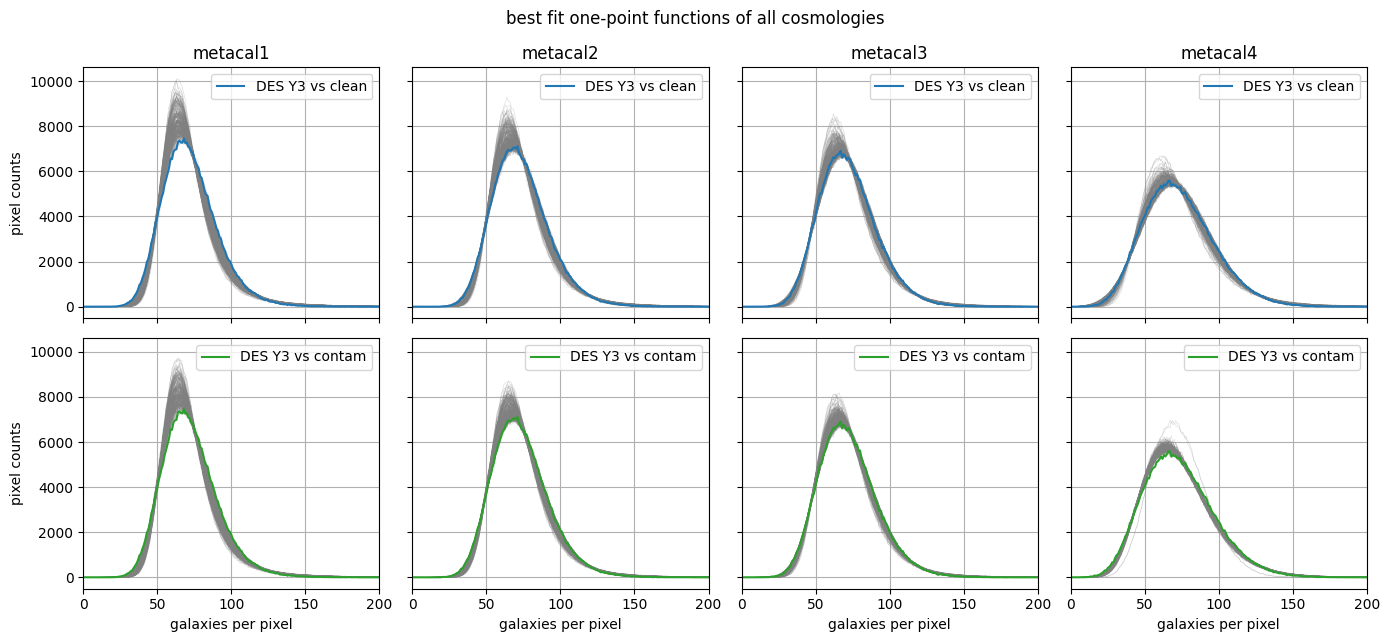

In [16]:
# all best fit one-point functions over the DES Y3 target, as in check_results of the reference script
fig, ax = plt.subplots(figsize=(14, 6.5), ncols=n_z, nrows=2, sharey=True, sharex=True)
for j, name in enumerate(arms):
    for i in range(n_z):
        for stat in stat_tables[name][::10, i]:
            ax[j, i].plot(centres, stat, alpha=0.3, lw=0.4, color="grey")
        ax[j, i].plot(centres, target[i], color=colors[name], lw=1.5, label=f"DES Y3 vs {name}")
        ax[j, i].set(title=z_bins[i] if j == 0 else None, xlim=(0, 200))
        ax[j, i].grid(True, zorder=0)
        ax[j, i].legend()
    ax[j, 0].set(ylabel="pixel counts")
for i in range(n_z):
    ax[-1, i].set(xlabel="galaxies per pixel")
fig.suptitle("best fit one-point functions of all cosmologies")
fig.tight_layout()

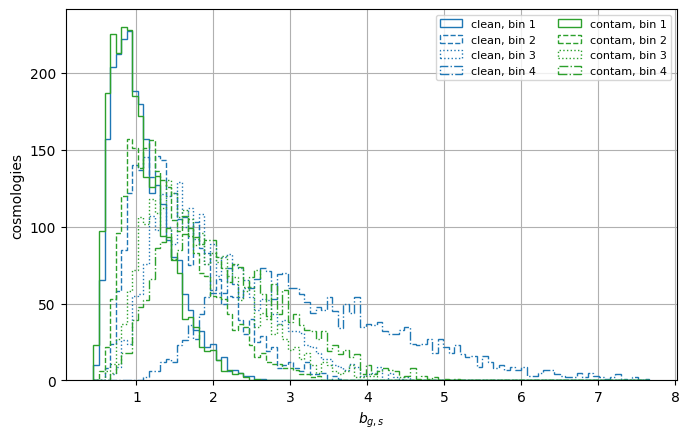

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
b_range = (min(t.min() for t in bias_tables.values()), max(t.max() for t in bias_tables.values()))
for name in arms:
    for i in range(n_z):
        ax.hist(bias_tables[name][:, i], bins=100, range=b_range, histtype="step",
                color=colors[name], ls=["-", "--", ":", "-."][i], label=f"{name}, bin {i + 1}")
ax.set(xlabel="$b_{g,s}$", ylabel="cosmologies")
ax.grid(True, zorder=0)
ax.legend(fontsize=8, ncols=2)
fig.tight_layout()

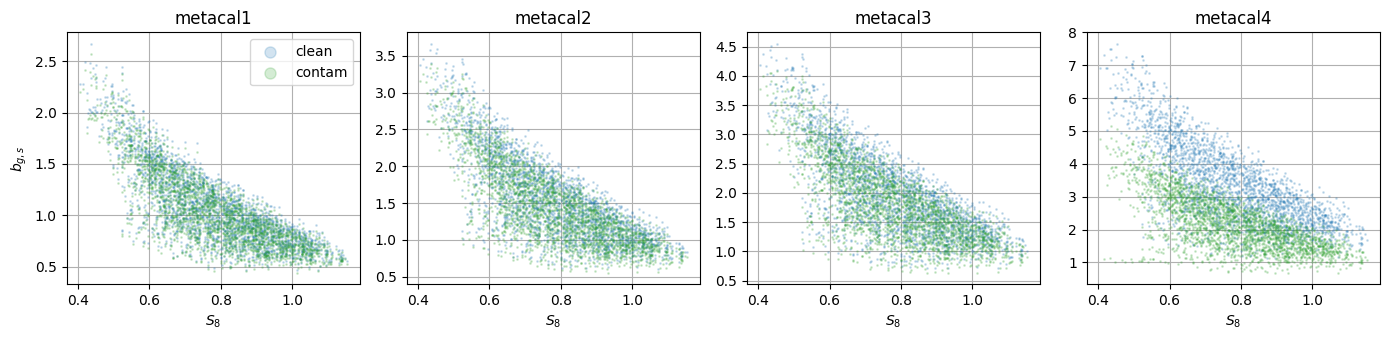

In [18]:
# cosmology dependence, as in notebooks/metacal_bias.ipynb
meta_info_file = os.path.join(repo_dir, conf["files"]["meta_info"])
params_grid = cosmogrid.get_cosmo_params_info(meta_info_file, simset="grid")

i_grid = [k != "fiducial" for k in keys]
key_to_row = {scb.cosmo_key(p): i for i, p in enumerate(params_grid["path_par"])}
rows = [key_to_row[k] for k in np.array(keys)[i_grid]]

Om = params_grid["Om"][rows].astype(float)
s8 = params_grid["s8"][rows].astype(float)
S8 = s8 * np.sqrt(Om / 0.3)

fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z, sharex=True)
for i in range(n_z):
    for name in arms:
        ax[i].scatter(S8, bias_tables[name][i_grid, i], s=1, alpha=0.2, color=colors[name], zorder=10, label=name)
    ax[i].set(xlabel="$S_8$", title=z_bins[i])
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="$b_{g,s}$")
ax[0].legend(markerscale=8)
fig.tight_layout()

### The effect of the contamination over the whole grid

The left panel is the direct comparison of the two arms, the right one puts both against the existing table. What to look for: a contamination that only adds a spatially varying survey systematic should pull the biases **down** by a roughly cosmology independent factor, largest in the highest tomographic bin, without scrambling their ordering.

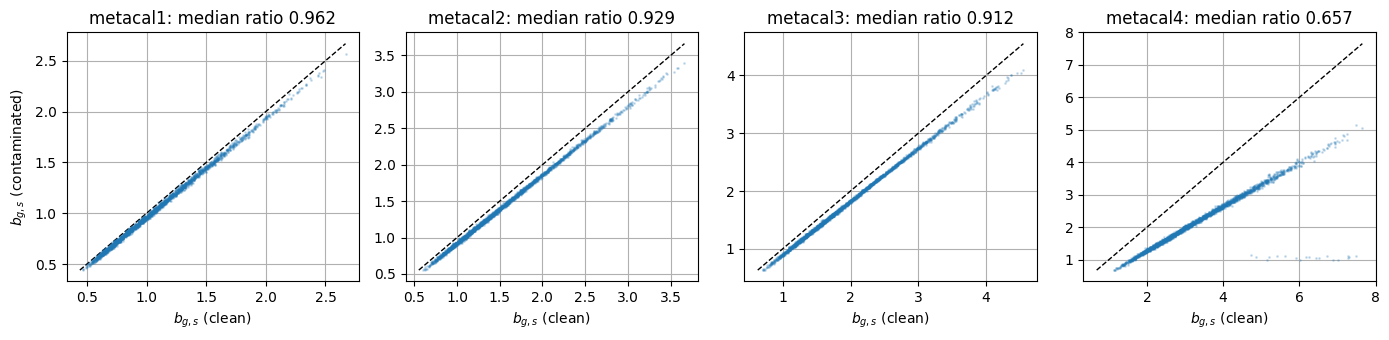

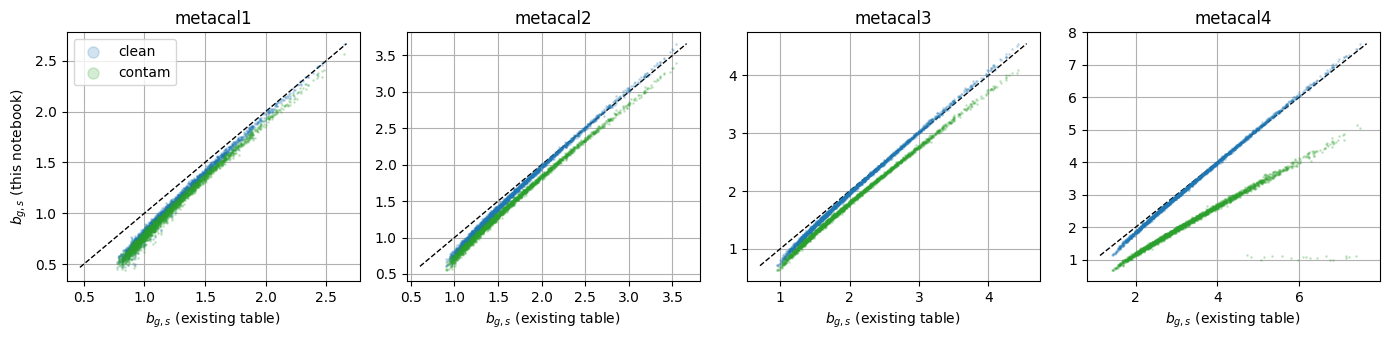

In [19]:
with h5py.File(old_file, "r") as f:
    bias_table_old = np.array([f[k][:] for k in keys])

fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z)
for i in range(n_z):
    ax[i].scatter(bias_tables["clean"][:, i], bias_tables["contam"][:, i], s=1, alpha=0.2, zorder=10)
    both = np.concatenate([bias_tables["clean"][:, i], bias_tables["contam"][:, i]])
    ax[i].plot([both.min(), both.max()], [both.min(), both.max()], color="black", lw=1, ls="--")
    ratio = bias_tables["contam"][:, i] / bias_tables["clean"][:, i]
    ax[i].set(xlabel="$b_{g,s}$ (clean)", title=f"{z_bins[i]}: median ratio {np.median(ratio):.3f}")
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="$b_{g,s}$ (contaminated)")
fig.tight_layout()

fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z)
for i in range(n_z):
    for name in arms:
        ax[i].scatter(bias_table_old[:, i], bias_tables[name][:, i], s=1, alpha=0.2, color=colors[name],
                      zorder=10, label=name)
    both = np.concatenate([bias_table_old[:, i], bias_tables["clean"][:, i]])
    ax[i].plot([both.min(), both.max()], [both.min(), both.max()], color="black", lw=1, ls="--")
    ax[i].set(xlabel="$b_{g,s}$ (existing table)", title=z_bins[i])
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="$b_{g,s}$ (this notebook)")
ax[0].legend(markerscale=8)
fig.tight_layout()

### How much does the contamination change $b$, cosmology by cosmology?

The scatter above shows the two arms are strongly correlated; this is the paired view of the *change*. The bias values are what the forward model actually consumes, so the question that matters is whether the contamination is a **constant rescaling** of $b$ (in which case it is degenerate with a recalibration of $\langle n_{g,s} \rangle$ and cannot matter for cosmology) or whether it **tilts across the grid** (in which case it changes the cosmology dependence the network is trained on).

The last row compares the fit losses. A contamination that genuinely explains part of the observed width should not make the fit *worse* — and at the fiducial cosmology it does exactly that in the highest bin, where $b$ drops by a third while the loss goes up. Whether that is a fiducial accident or a grid-wide feature is the one loose end of this calibration.

bin          median     16th     84th    median loss clean   contam  % worse
metacal1     0.9616   0.9462   0.9757               1.5841   1.4761      2.3
metacal2     0.9292   0.9163   0.9383               0.8726   0.7797     16.8
metacal3     0.9117   0.9008   0.9199               0.4911   0.4691     35.7
metacal4     0.6566   0.6378   0.6697               0.4801   0.8642     77.0


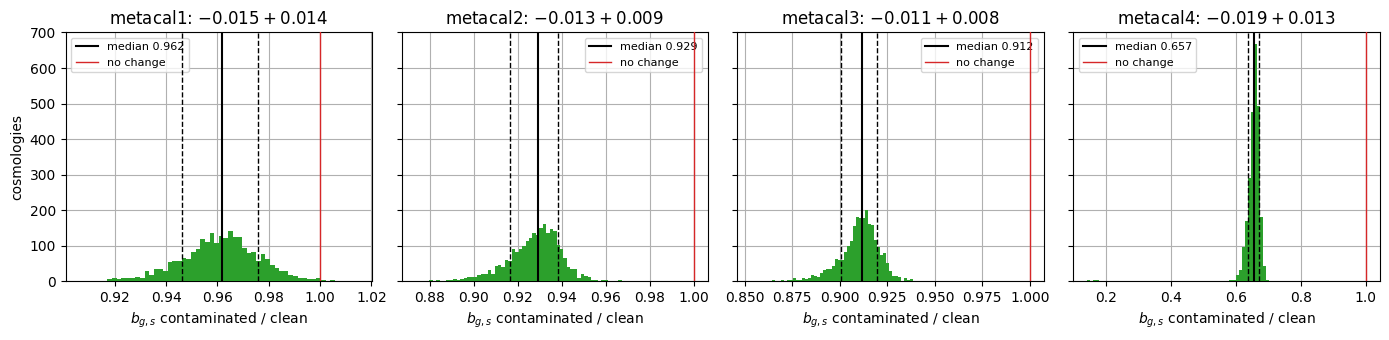

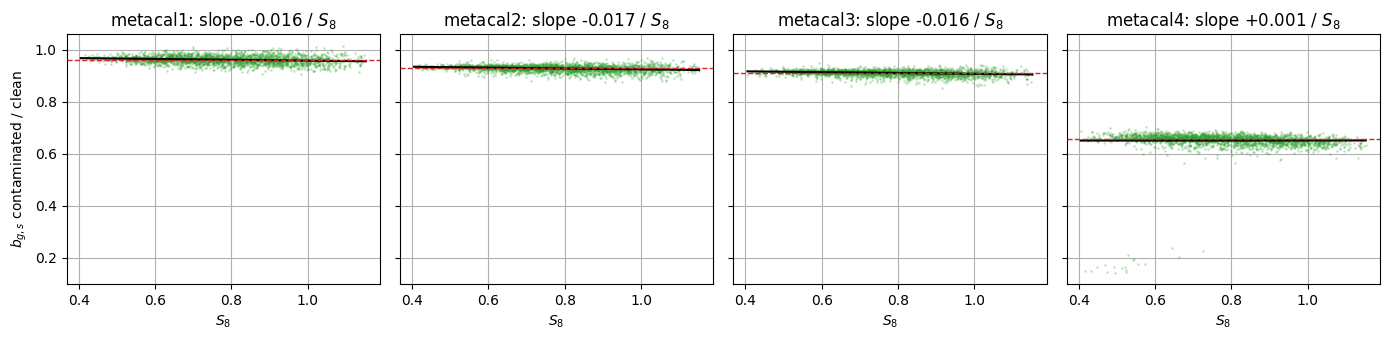

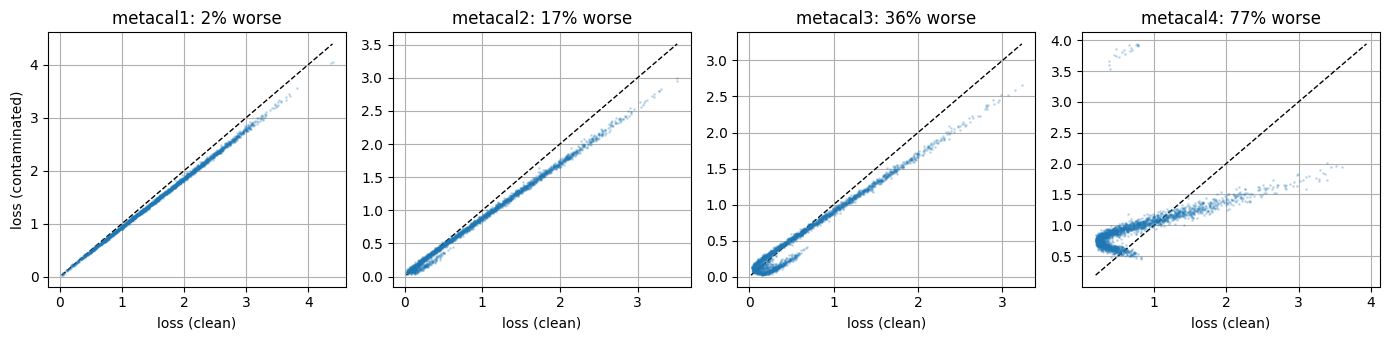

In [20]:
ratio = bias_tables["contam"] / bias_tables["clean"]

# how much the contamination takes out of b, and how cosmology dependent that is
fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z, sharey=True)
for i in range(n_z):
    lo, med, hi = np.percentile(ratio[:, i], [16, 50, 84])
    ax[i].hist(ratio[:, i], bins=60, color=colors["contam"], zorder=10)
    ax[i].axvline(med, color="black", lw=1.5, zorder=20, label=f"median {med:.3f}")
    for q in (lo, hi):
        ax[i].axvline(q, color="black", lw=1, ls="--", zorder=20)
    ax[i].axvline(1.0, color="C3", lw=1, zorder=20, label="no change")
    ax[i].set(xlabel="$b_{g,s}$ contaminated / clean", title=f"{z_bins[i]}: $-{med - lo:.3f} + {hi - med:.3f}$")
    ax[i].grid(True, zorder=0)
    ax[i].legend(fontsize=8)
ax[0].set(ylabel="cosmologies")
fig.tight_layout()

# a constant rescaling would be a flat line here, a tilt means the cosmology dependence itself changed
fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z, sharey=True)
for i in range(n_z):
    ax[i].scatter(S8, ratio[i_grid, i], s=1, alpha=0.2, color=colors["contam"], zorder=10)
    slope, intercept = np.polyfit(S8, ratio[i_grid, i], deg=1)
    ax[i].plot(np.sort(S8), intercept + slope * np.sort(S8), color="black", lw=1.5, zorder=20)
    ax[i].axhline(np.median(ratio[:, i]), color="C3", lw=1, ls="--", zorder=20)
    ax[i].set(xlabel="$S_8$", title=f"{z_bins[i]}: slope {slope:+.3f} / $S_8$")
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="$b_{g,s}$ contaminated / clean")
fig.tight_layout()

# does the contaminated model actually fit the observation better?
fig, ax = plt.subplots(figsize=(14, 3.5), ncols=n_z)
for i in range(n_z):
    ax[i].scatter(loss_tables["clean"][:, i], loss_tables["contam"][:, i], s=1, alpha=0.2, zorder=10)
    both = np.concatenate([loss_tables["clean"][:, i], loss_tables["contam"][:, i]])
    ax[i].plot([both.min(), both.max()], [both.min(), both.max()], color="black", lw=1, ls="--")
    f_worse = np.mean(loss_tables["contam"][:, i] > loss_tables["clean"][:, i])
    ax[i].set(xlabel="loss (clean)", title=f"{z_bins[i]}: {100 * f_worse:.0f}% worse")
    ax[i].grid(True, zorder=0)
ax[0].set(ylabel="loss (contaminated)")
fig.tight_layout()

print(f"{'bin':<10} {'median':>8} {'16th':>8} {'84th':>8}   {'median loss clean':>18} {'contam':>8} {'% worse':>8}")
for i in range(n_z):
    lo, med, hi = np.percentile(ratio[:, i], [16, 50, 84])
    l_clean, l_contam = np.median(loss_tables["clean"][:, i]), np.median(loss_tables["contam"][:, i])
    f_worse = 100 * np.mean(loss_tables["contam"][:, i] > loss_tables["clean"][:, i])
    print(f"{z_bins[i]:<10} {med:>8.4f} {lo:>8.4f} {hi:>8.4f}   {l_clean:>18.4f} {l_contam:>8.4f} {f_worse:>8.1f}")